# Can Money Buy Olympic Success?
**DTU 02806 — Social Data Analysis and Visualization | Spring 2026**  
Group 82: Nick Tahmasebi, Filip Sahakian, Destin Zhong

---
**Website:** [nicktahmasebi.github.io](https://nicktahmasebi.github.io)

## 1. Motivation

### What is your dataset?
Three datasets were combined:
- **120 Years of Olympic History** (Kaggle, heesoo37): athlete-level records for every Olympic Games from 1896–2016, including medal outcomes, sport, event, and NOC code.
- **World Bank GDP** (`NY.GDP.MKTP.CD`): annual GDP in current USD for all countries, 1960–2016.
- **World Bank Population** (`SP.POP.TOTL`): annual population for all countries, 1960–2016.

### Why this dataset?
The Olympics produce one of the most detailed longitudinal records of national competition. A single ranked outcome every four years, across more than 150 countries, over six decades. Combined with economic data, it offers a rare opportunity to test whether national wealth actually predicts sporting dominance, or whether other factors dominate.

### Goal for the end user
A non-technical reader should be able to explore the relationship between GDP and Olympic performance, discover which countries consistently punch above or below their economic weight, and understand why raw medal counts are a misleading measure of Olympic efficiency - all without needing to understand the underlying data pipeline.

## 2. Basic Stats

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df  = pd.read_csv('athlete_events.csv')
gdp = pd.read_csv('gdp.csv', skiprows=4)
pop = pd.read_csv('population.csv', skiprows=4)

### Data Cleaning & Preprocessing

**Scope filter:** Analysis is restricted to Summer Olympics from 1960 onwards. Pre-1960 data is excluded because GDP records are sparse and the geopolitical landscape (colonial territories, Cold War bloc formation) makes country-level comparisons unreliable.

**Team event deduplication:** The raw dataset contains one row per athlete, meaning team sports (e.g. relay races, football) inflate medal counts. Duplicates were removed by keeping one row per `(Year, Event, Medal, NOC)` combination.

**Nation chain stitching:** Several countries competed under different NOC codes across the study period due to political changes:
- `GDR`, `FRG`, `GER` → unified as **Germany**
- `URS`, `EUN`, `RUS` → unified as **Russia/USSR**

**GDP merge:** World Bank GDP data is in wide format (one column per year). It was melted to long format and merged with medal data on `(NOC, Year)` after aligning country codes via the `noc_regions` lookup table.

**Missing GDP data:** Countries with no GDP record for a given Olympic year are excluded from efficiency calculations but retained for raw medal counts.

In [23]:
# Dataset overview
summer = df[df['Season'] == 'Summer']
post60 = summer[summer['Year'] >= 1960]

print(f"Total athlete-event rows (all time):      {len(df):,}")
print(f"Summer Games rows (1960–2016):            {len(post60):,}")
print(f"Unique NOC codes:                         {post60['NOC'].nunique()}")
print(f"Unique sports:                            {post60['Sport'].nunique()}")
print(f"Olympic Games covered:                    {sorted(post60['Year'].unique())}")
print(f"\nMissing values in key columns:")
print(post60[['Name','NOC','Sport','Event','Medal']].isnull().sum())

Total athlete-event rows (all time):      271,116
Summer Games rows (1960–2016):            166,267
Unique NOC codes:                         223
Unique sports:                            36
Olympic Games covered:                    [np.int64(1960), np.int64(1964), np.int64(1968), np.int64(1972), np.int64(1976), np.int64(1980), np.int64(1984), np.int64(1988), np.int64(1992), np.int64(1996), np.int64(2000), np.int64(2004), np.int64(2008), np.int64(2012), np.int64(2016)]

Missing values in key columns:
Name          0
NOC           0
Sport         0
Event         0
Medal    142722
dtype: int64


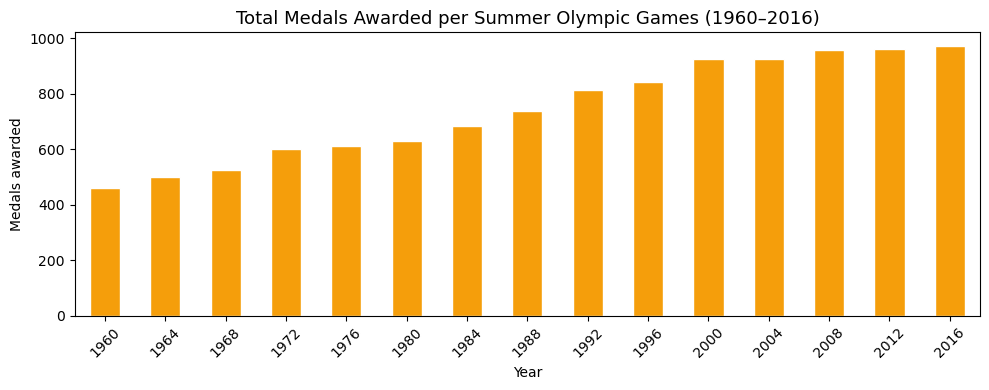

In [24]:
# Medals per Games over time — participation growth
medals_by_year = (post60[post60['Medal'].notna()]
                  .drop_duplicates(subset=['Year','Event','Medal','NOC'])
                  .groupby('Year').size())

fig, ax = plt.subplots(figsize=(10, 4))
medals_by_year.plot(kind='bar', ax=ax, color='#f59e0b', edgecolor='white')
ax.set_title('Total Medals Awarded per Summer Olympic Games (1960–2016)', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Medals awarded')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Key EDA Findings

Total deduplicated medals (Summer, 1960–2016): 11,154
Top 10 countries account for 51.7% of all medals

Top 10 by medal count:
NOC
USA    1458
URS     837
CHN     542
GER     471
RUS     452
GBR     437
AUS     412
GDR     409
ITA     374
FRA     370


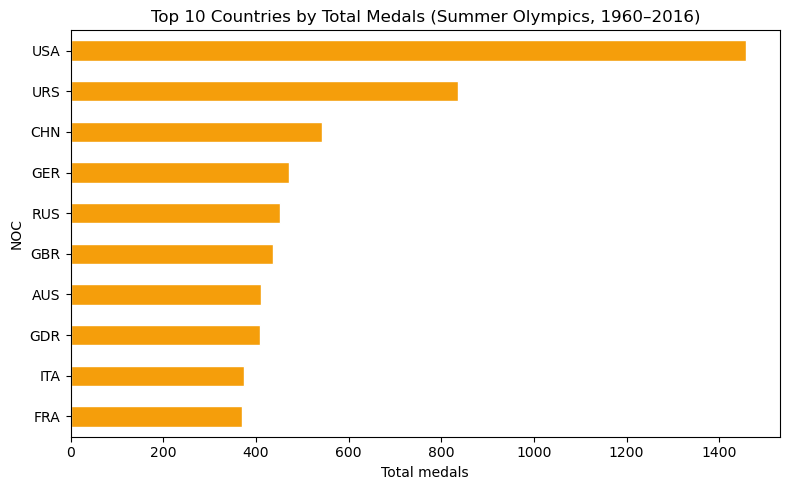

In [25]:
# ── 1. Concentration: top 10 countries account for the majority of medals ─────
medals_dedup = (post60[post60['Medal'].notna()]
                .drop_duplicates(subset=['Year','Event','Medal','NOC']))

top10 = (medals_dedup.groupby('NOC').size()
         .sort_values(ascending=False)
         .head(10))

total = len(medals_dedup)
top10_share = top10.sum() / total * 100

print(f"Total deduplicated medals (Summer, 1960–2016): {total:,}")
print(f"Top 10 countries account for {top10_share:.1f}% of all medals\n")
print("Top 10 by medal count:")
print(top10.to_string())

fig, ax = plt.subplots(figsize=(8, 5))
top10.sort_values().plot(kind='barh', ax=ax, color='#f59e0b', edgecolor='white')
ax.set_title('Top 10 Countries by Total Medals (Summer Olympics, 1960–2016)', fontsize=12)
ax.set_xlabel('Total medals')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

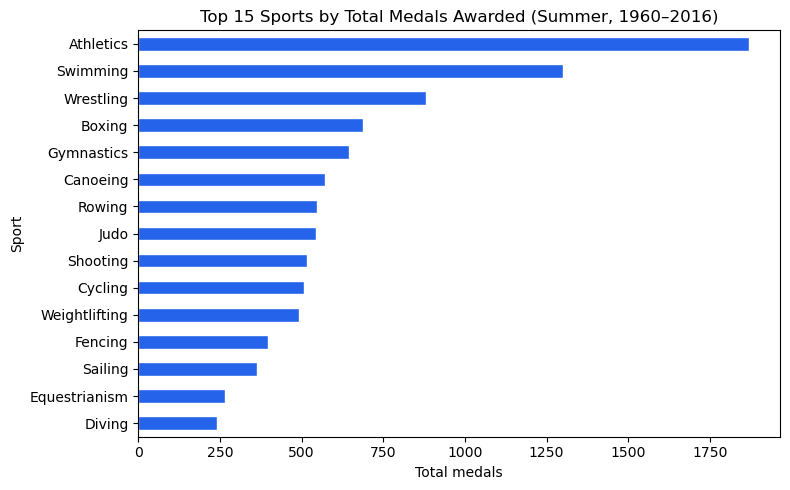


Athletics alone accounts for 16.8% of all medals
Top 3 sports account for 36.3% of all medals


In [26]:
# ── 2. Sport distribution: which sports produce the most medals ───────────────
sport_medals = (medals_dedup.groupby('Sport').size()
                .sort_values(ascending=False)
                .head(15))

fig, ax = plt.subplots(figsize=(8, 5))
sport_medals.sort_values().plot(kind='barh', ax=ax, color='#2563eb', edgecolor='white')
ax.set_title('Top 15 Sports by Total Medals Awarded (Summer, 1960–2016)', fontsize=12)
ax.set_xlabel('Total medals')
ax.set_facecolor('white')
fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

print(f"\nAthletics alone accounts for {sport_medals['Athletics']/total*100:.1f}% of all medals")
print(f"Top 3 sports account for {sport_medals.head(3).sum()/total*100:.1f}% of all medals")

In [27]:
# ── 3. GDP coverage: how well does the World Bank data cover Olympic nations ───
year_cols = [c for c in gdp.columns if c.isdigit() and 1960 <= int(c) <= 2016]
gdp_long  = (gdp[['Country Code'] + year_cols]
             .melt(id_vars='Country Code', var_name='Year', value_name='gdp_usd')
             .rename(columns={'Country Code': 'NOC'}))
gdp_long['Year'] = gdp_long['Year'].astype(int)

olympic_nocs   = set(medals_dedup['NOC'].unique())
gdp_nocs       = set(gdp_long.dropna(subset=['gdp_usd'])['NOC'].unique())
covered        = olympic_nocs & gdp_nocs
missing_gdp    = olympic_nocs - gdp_nocs

medals_with_gdp    = medals_dedup[medals_dedup['NOC'].isin(covered)]
gdp_medal_coverage = len(medals_with_gdp) / total * 100

print(f"Unique NOCs in medal data:          {len(olympic_nocs)}")
print(f"NOCs with GDP data available:       {len(covered)}  ({len(covered)/len(olympic_nocs)*100:.0f}%)")
print(f"NOCs missing GDP data:              {len(missing_gdp)}")
print(f"Medal rows covered by GDP data:     {gdp_medal_coverage:.1f}%")
print(f"\nNOCs without GDP data (excluded from efficiency analysis):")
print(sorted(missing_gdp))

Unique NOCs in medal data:          142
NOCs with GDP data available:       84  (59%)
NOCs missing GDP data:              58
Medal rows covered by GDP data:     70.6%

NOCs without GDP data (excluded from efficiency analysis):
['AHO', 'ALG', 'BAH', 'BAR', 'BER', 'BOT', 'BUL', 'CRC', 'CRO', 'DEN', 'EUN', 'FIJ', 'FRG', 'GDR', 'GER', 'GRE', 'GRN', 'GUA', 'INA', 'IOA', 'IRI', 'ISV', 'KOS', 'KSA', 'KUW', 'LAT', 'LIB', 'MAS', 'MGL', 'MRI', 'NED', 'NGR', 'NIG', 'PAR', 'PHI', 'POR', 'PRK', 'PUR', 'RSA', 'SCG', 'SLO', 'SRI', 'SUD', 'SUI', 'TAN', 'TCH', 'TGA', 'TOG', 'TPE', 'UAE', 'UAR', 'URS', 'URU', 'VIE', 'WIF', 'YUG', 'ZAM', 'ZIM']


## 3. Data Analysis

### Efficiency Metric

Raw medal counts are misleading because countries compete with vastly different economic resources. A country with 25% of global GDP winning 25% of medals is unremarkable — one with 0.04% of GDP winning 1.4% of medals is extraordinary.

We define an **efficiency score** as:

$$\text{Efficiency} = \frac{\text{Actual medals won}}{\text{Expected medals based on GDP share}}$$

Where expected medals = `(country GDP / world GDP) × total medals that year`.

- Score **= 1.0** → wins exactly what GDP predicts  
- Score **> 1.0** → outperforms economic weight  
- Score **< 1.0** → underperforms relative to economic size

This metric is computed per country per Olympic year, then averaged across all participation years for each country.

In [28]:
# Melt GDP to long format
year_cols = [c for c in gdp.columns if c.isdigit()]
gdp_long  = (gdp[['Country Code'] + year_cols]
             .melt(id_vars='Country Code', var_name='Year', value_name='gdp_usd')
             .rename(columns={'Country Code': 'NOC'}))
gdp_long['Year'] = gdp_long['Year'].astype(int)

# Deduplicate medals and merge
medals = (df[(df['Season']=='Summer') & (df['Year']>=1960) & df['Medal'].notna()]
          .drop_duplicates(subset=['Year','Event','Medal','NOC'])
          .copy())

medals = medals.merge(gdp_long, on=['NOC','Year'], how='left')

# World GDP and total medals per year
world_gdp    = medals.groupby('Year')['gdp_usd'].sum().rename('world_gdp')
total_medals = medals.groupby('Year').size().rename('total_medals')
medals       = medals.join(world_gdp,    on='Year').join(total_medals, on='Year')

# Efficiency score
medals['expected']          = (medals['gdp_usd'] / medals['world_gdp']) * medals['total_medals']
medals['efficiency_score']  = 1 / medals['expected']  # per medal row; averaged later

# Country-level averages
country_eff = (medals[medals['gdp_usd'].notna()]
               .groupby('NOC')
               .agg(avg_eff=('efficiency_score','mean'),
                    games=('Year','count'),
                    total_medals=('total_medals','sum'))
               .query('games >= 3')
               .sort_values('avg_eff', ascending=False))

print("Top 10 most efficient countries (GDP-adjusted):")
print(country_eff.head(10)[['avg_eff','games','total_medals']])

Top 10 most efficient countries (GDP-adjusted):
        avg_eff  games  total_medals
NOC                                 
MDA  744.693974      7          6413
KGZ  744.398818      3          2839
TJK  552.541759      4          3849
ARM  411.332659     16         15127
NAM  346.499681      4          3308
GEO  314.886929     32         30227
BRN  296.832144      3          2908
ISL  243.346137      3          2567
CHI  238.081335      4          3706
JAM  225.661359     68         59895


## 4. Genre

### Which genre did we use?

The website follows the **Magazine** genre from Segel & Heer (2010) — a long-form scrollable narrative with embedded interactive visualizations, written for a general audience.

---

### Visual Narrative (Figure 7, Segel & Heer)

| Category | Tool used | Why |
|---|---|---|
| **Visual Structuring** | Consistent color encoding (amber = overperformer, blue = underperformer) across all charts | Lets readers build intuition once and apply it everywhere |
| **Highlighting** | Annotated country labels on scatter plots | Draws attention to key outliers without cluttering the full dataset |
| **Transition Guidance** | Section headers and bridging text between each visualization block | Maintains narrative thread as the reader scrolls |

### Narrative Structure (Figure 7, Segel & Heer)

| Category | Tool used | Why |
|---|---|---|
| **Ordering** | Author-driven linear scroll, top to bottom | Introduces the hierarchy first, then complicates it with the efficiency metric |
| **Interactivity** | Reader-driven exploration via Plotly dropdowns (fingerprint chart) and hover tooltips (all charts) | Allows readers to test their own country comparisons without leaving the page |
| **Messaging** | Pull-quote formula blocks (efficiency definition) and side-by-side country examples | Makes the core metric immediately concrete before showing charts |

## 5. Visualizations

### Top 10 Olympic Nations (Bar Chart)
A horizontal bar chart showing total medals per country from 1960–2016. **Why:** Establishes the raw hierarchy quickly. The dominance of the USA and USSR/Russia is the opening observation the rest of the article complicates.

---

### GDP World Map (Choropleth)
A choropleth showing average national GDP across the study period, bucketed into five tiers. **Why:** Placed directly beside the medal chart, the visual similarity between the two maps makes the GDP–medals correlation immediately visible before any analysis is presented.

---

### Overachievers & Underachievers (Bar Chart)
Two horizontal bar charts showing the top 20 countries by efficiency score and the bottom 15 large-economy underperformers. **Why:** The efficiency metric is abstract — the bar chart makes it concrete by naming specific countries and showing the magnitude of their over/underperformance.

---

### GDP vs Medal Efficiency (Scatter Plot)
Log-scale scatter with amber (top 15% efficiency) and blue (large economy, low efficiency) coloring, and a dashed reference line at efficiency = 1.0. Country labels highlight key nations. **Why:** Shows the full distribution across all countries and makes it clear that high GDP does not guarantee high efficiency.

---

### Population vs Medal Efficiency (Scatter Plot)
Same color scheme as the GDP scatter, with a dashed reference line at the global average (medals per million people). **Why:** Tests a second hypothesis — that population size drives Olympic success — and shows the same weak relationship, reinforcing that neither raw resource explains efficiency.

---

### Medal Specialization Fingerprints (Interactive Polar Chart)
A dual polar bar chart where readers select one low-GDP and one high-GDP country from dropdown menus. Bar length encodes medal volume (sqrt-normalized); bars are side-by-side per sport to prevent overlap. **Why:** Shows that countries do not just win more or fewer medals — they win them in structurally different ways. Small nations specialize; wealthy nations diversify. The interactive comparison makes this tangible.

## 6. Discussion

### What went well
- The efficiency metric successfully reframes Olympic success and produces counterintuitive, interesting results (Georgia and Mongolia outperforming France and Brazil).
- Consistent color encoding (amber/blue/grey) across all scatter charts means readers only need to learn the visual language once.
- The fingerprint chart effectively communicates specialization vs diversification as a structural difference, not just a scale difference.
- The magazine format keeps the website readable for a non-technical audience while the notebook provides depth for interested readers.

### What is still missing / could be improved
- **Temporal dimension:** All scatter plots show averages across 1960–2016. An animated or year-sliced view would show how countries' efficiency scores changed over time (e.g. China's rise after 1984, the collapse of the Soviet bloc).
- **Confounding factors:** The efficiency metric controls for GDP but not for other predictors — political investment in sport, climate, altitude training access, or population age structure. A multivariate model would be more rigorous.
- **Sport coverage in fingerprints:** The polar chart covers 16 sports but the Olympics has over 30. Sports like Shooting, Badminton, and Canoeing are excluded, which means some countries' fingerprints are incomplete (notably India and Hungary).
- **Doping context:** The dataset does not flag stripped medals, meaning some efficiency scores (especially Eastern Bloc nations in the 1970s–80s) are likely inflated.

## 7. Contributions

| Member | Main responsibilities |
|---|---|
| **Nick Tahmasebi** | Website design and layout (HTML/CSS/Tailwind), data cleaning, Top 10 nations bar chart, GDP world map, overall narrative structure and written copy |
| **Filip Sahakian** | Efficiency metric design and implementation, GDP vs efficiency scatter, population vs efficiency scatter, Medal Specialization Fingerprints chart, data pipeline and merges |
| **Destin Zhong** | Overachievers/underachievers bar chart, exploratory data analysis, data preprocessing, nation chain stitching (GDR/FRG/GER, URS/EUN/RUS) |

## 8. References

1. Griffin, R. (2018). *120 Years of Olympic History: Athletes and Results.* Kaggle. https://www.kaggle.com/datasets/heesoo37/120-years-of-olympic-history-athletes-and-results

2. World Bank. *GDP (current US$).* World Bank National Accounts Data. https://data.worldbank.org/indicator/NY.GDP.MKTP.CD

3. World Bank. *Population, total.* World Bank National Accounts Data. https://data.worldbank.org/indicator/SP.POP.TOTL

4. International Olympic Committee. *Olympic Games Results and History.* https://www.olympic.org/olympic-games

5. Bernard, A. B. & Busse, M. R. (2004). Who Wins the Olympic Games: Economic Resources and Medal Totals. *Review of Economics and Statistics,* 86(1), 413–417.